In [14]:
import os
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    matthews_corrcoef,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt

In [2]:
SEED = 42

IMAGE_SIZE = 224
NUM_CLASSES = 6
BATCH_SIZE = 32

CLASS_NAMES = [
    "MT_Blowhole",
    "MT_Break",
    "MT_Crack",
    "MT_Fray",
    "MT_Free",
    "MT_Uneven"
]

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cuda


In [3]:
random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [4]:
PROJECT_ROOT = Path.cwd().parent

DATASET_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "magnetic_tile"
)

print(DATASET_PATH)

image_paths = []
labels = []

for label, class_name in enumerate(CLASS_NAMES):

    image_folder = (
        DATASET_PATH
        / class_name
        / "Imgs"
    )

    paths = sorted(
        image_folder.glob("*.jpg")
    )

    image_paths.extend(paths)

    labels.extend(
        [label] * len(paths)
    )

print("Total images:", len(image_paths))

d:\Study\industrial_visual_inspection\data\raw\magnetic_tile
Total images: 1344


In [5]:
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.30,
    stratify=labels,
    random_state=SEED
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.50,
    stratify=temp_labels,
    random_state=SEED
)

print("Train:", len(train_paths))
print("Validation:", len(val_paths))
print("Test:", len(test_paths))

test_distribution = Counter(test_labels)

print("Test class distribution:\n")

for class_idx, count in sorted(test_distribution.items()):
    print(
        f"{CLASS_NAMES[class_idx]:15s}: {count}"
    )

print("\nTest class percentages:\n")

total_test = len(test_labels)

for class_idx, count in sorted(test_distribution.items()):
    percentage = (
        count / total_test
    ) * 100

    print(
        f"{CLASS_NAMES[class_idx]:15s}: "
        f"{percentage:.2f}%"
    )

Train: 940
Validation: 202
Test: 202
Test class distribution:

MT_Blowhole    : 18
MT_Break       : 12
MT_Crack       : 9
MT_Fray        : 5
MT_Free        : 143
MT_Uneven      : 15

Test class percentages:

MT_Blowhole    : 8.91%
MT_Break       : 5.94%
MT_Crack       : 4.46%
MT_Fray        : 2.48%
MT_Free        : 70.79%
MT_Uneven      : 7.43%


In [6]:
# Recreating the Test Transformations
val_test_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.Grayscale(
        num_output_channels=3
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],
        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])

In [7]:
# Dataset Class
class MagneticTileDataset(Dataset):

    def __init__(
        self,
        image_paths,
        labels,
        transform=None
    ):

        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):

        return len(self.image_paths)

    def __getitem__(self, idx):

        image = Image.open(
            self.image_paths[idx]
        ).convert("L")

        label = self.labels[idx]

        if self.transform is not None:

            image = self.transform(image)

        return image, label

test_dataset = MagneticTileDataset(
    test_paths,
    test_labels,
    val_test_transform
)

In [8]:
# Test DataLoader
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)
images, labels = next(
    iter(test_loader)
)

print("Images:", images.shape)
print("Labels:", labels.shape)
print("Image dtype:", images.dtype)
print("Label dtype:", labels.dtype)

Images: torch.Size([32, 3, 224, 224])
Labels: torch.Size([32])
Image dtype: torch.float32
Label dtype: torch.int64


In [9]:
model_partial3_4 = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

# Replace the final classification layer
model_partial3_4.fc = nn.Linear(
    model_partial3_4.fc.in_features,
    NUM_CLASSES
)

# Freeze the early layers
for param in model_partial3_4.conv1.parameters():
    param.requires_grad = False

for param in model_partial3_4.layer1.parameters():
    param.requires_grad = False

for param in model_partial3_4.layer2.parameters():
    param.requires_grad = False

# Keep deeper layers trainable
for param in model_partial3_4.layer3.parameters():
    param.requires_grad = True

for param in model_partial3_4.layer4.parameters():
    param.requires_grad = True

for param in model_partial3_4.fc.parameters():
    param.requires_grad = True

model_partial3_4 = model_partial3_4.to(device)
# Check Total Trainable Parameters
trainable_params = sum(
    p.numel()
    for p in model_partial3_4.parameters()
    if p.requires_grad
)

total_params = sum(
    p.numel()
    for p in model_partial3_4.parameters()
)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
# Load the Best Checkpoints
checkpoint_path = (
    PROJECT_ROOT
    / "notebooks"
    / "best_resnet18_partial3_4.pth"
)

model_partial3_4.load_state_dict(
    torch.load(
        checkpoint_path,
        map_location=device
    )
)

model_partial3_4.eval()

print("Best ResNet18 Partial FT model loaded.")

Total parameters: 11,179,590
Trainable parameters: 10,496,646
Best ResNet18 Partial FT model loaded.


### Grad-Cam Setup

For ResNet18, the appropriate target layer is the last convolutional block, i.e.:

In [10]:
model_partial3_4.layer4[-1]

BasicBlock(
  (conv1): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
)

In [15]:
# Run the Test Set Inference
all_true_labels = []
all_pred_labels = []
all_probabilities = []
all_image_paths = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model_partial3_4(images)

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        predictions = torch.argmax(
            probabilities,
            dim=1
        )

        all_true_labels.extend(
            labels.cpu().numpy()
        )

        all_pred_labels.extend(
            predictions.cpu().numpy()
        )

        all_probabilities.extend(
            probabilities.cpu().numpy()
        )
all_probabilities = np.array(
    all_probabilities
)

all_true_labels = np.array(
    all_true_labels
)

all_pred_labels = np.array(
    all_pred_labels
)
# Recheck the Basic Metrics
accuracy = accuracy_score(
    all_true_labels,
    all_pred_labels
)

balanced_accuracy = balanced_accuracy_score(
    all_true_labels,
    all_pred_labels
)

macro_f1 = f1_score(
    all_true_labels,
    all_pred_labels,
    average="macro"
)

mcc = matthews_corrcoef(
    all_true_labels,
    all_pred_labels
)

print(f"Accuracy:           {accuracy:.4f}")
print(f"Balanced Accuracy:  {balanced_accuracy:.4f}")
print(f"Macro F1:           {macro_f1:.4f}")
print(f"MCC:                {mcc:.4f}")
predicted_confidence = (
    np.max(
        all_probabilities,
        axis=1
    )
)

top2_indices = np.argsort(
    all_probabilities,
    axis=1
)[:, -2:]

top2_indices = top2_indices[:, ::-1]

top1_indices = top2_indices[:, 0]
top2_indices_only = top2_indices[:, 1]

top1_probabilities = (
    all_probabilities[
        np.arange(len(all_probabilities)),
        top1_indices
    ]
)

top2_probabilities = (
    all_probabilities[
        np.arange(len(all_probabilities)),
        top2_indices_only
    ]
)

prediction_margin = (
    top1_probabilities -
    top2_probabilities
)
error_df = pd.DataFrame({

    "image_path": [
        str(path)
        for path in test_paths
    ],

    "true_label": all_true_labels,

    "true_class": [
        CLASS_NAMES[i]
        for i in all_true_labels
    ],

    "predicted_label": all_pred_labels,

    "predicted_class": [
        CLASS_NAMES[i]
        for i in all_pred_labels
    ],

    "confidence": predicted_confidence,

    "top2_class": [
        CLASS_NAMES[i]
        for i in top2_indices_only
    ],

    "top2_probability": top2_probabilities,

    "margin": prediction_margin,

    "correct": (
        all_true_labels ==
        all_pred_labels
    )
})

Accuracy:           0.9455
Balanced Accuracy:  0.8740
Macro F1:           0.8856
MCC:                0.8852


### Select the target Layer


In [17]:
target_layers = [
    model_partial3_4.layer4[-1]
]

#Initialize GradCam
cam = GradCAM(
    model=model_partial3_4,
    target_layers=target_layers
)

In [18]:
# Function To generate GradCam Results
def generate_gradcam(
    image_path,
    model,
    cam,
    transform,
    class_names,
    device
):

    # Load original image
    original_image = Image.open(
        image_path
    ).convert("L")

    # Resize for display
    display_image = original_image.resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    )

    # Convert grayscale image to RGB
    rgb_image = np.array(
        display_image
    ).astype(np.float32) / 255.0

    rgb_image = np.stack(
        [rgb_image] * 3,
        axis=-1
    )

    # Prepare model input
    input_tensor = transform(
        original_image
    ).unsqueeze(0).to(device)

    # Get prediction
    model.eval()

    with torch.no_grad():

        output = model(
            input_tensor
        )

        probabilities = torch.softmax(
            output,
            dim=1
        )

        predicted_class = (
            probabilities.argmax(
                dim=1
            ).item()
        )

        confidence = (
            probabilities[0, predicted_class]
            .item()
        )

    # Target the predicted class
    targets = [
        ClassifierOutputTarget(
            predicted_class
        )
    ]

    # Generate CAM
    grayscale_cam = cam(
        input_tensor=input_tensor,
        targets=targets
    )[0]

    # Overlay CAM on image
    visualization = show_cam_on_image(
        rgb_image,
        grayscale_cam,
        use_rgb=True
    )

    return (
        display_image,
        visualization,
        predicted_class,
        confidence
    )
    

In [31]:
# Test on the Correct Predictions
correct_example = error_df[
    error_df["correct"]
].iloc[75]

original, visualization, predicted_class, confidence = (
    generate_gradcam(
        image_path=correct_example["image_path"],
        model=model_partial3_4,
        cam=cam,
        transform=val_test_transform,
        class_names=CLASS_NAMES,
        device=device
    )
)

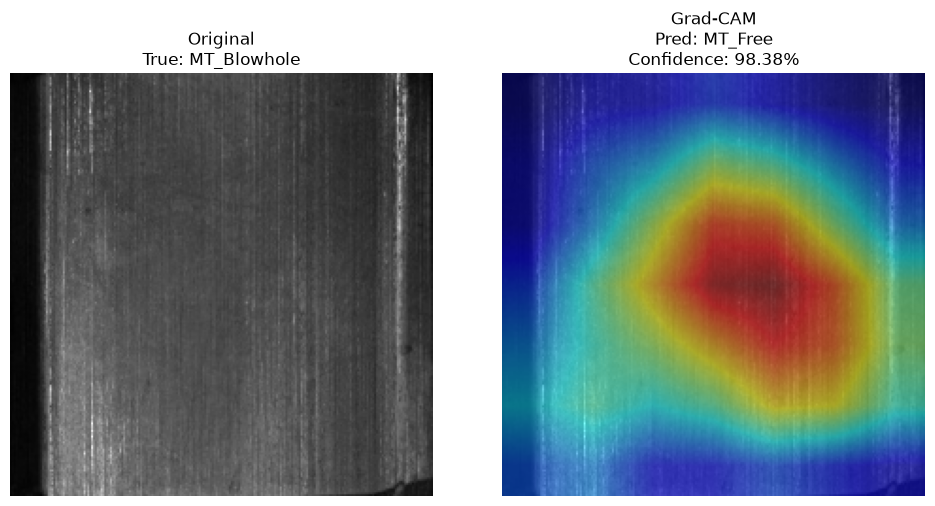

In [42]:
# Display it
fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 5)
)

axes[0].imshow(
    original,
    cmap="gray"
)

axes[0].set_title(
    f"Original\n"
    f"True: {correct_example['true_class']}"
)

axes[0].axis("off")

axes[1].imshow(
    visualization
)

axes[1].set_title(
    f"Grad-CAM\n"
    f"Pred: {CLASS_NAMES[predicted_class]}\n"
    f"Confidence: {confidence:.2%}"
)

axes[1].axis("off")
plt.savefig(PROJECT_ROOT / "outputs/figures/Correct_classified-gradcam.jpg")
plt.tight_layout()
plt.show()


### Testing on a Misclassified Image

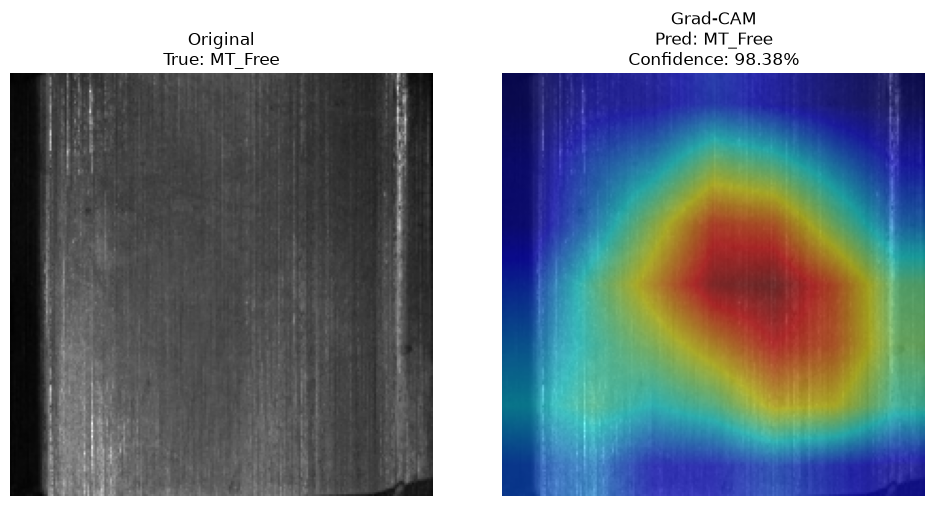

In [41]:
error_example = error_df.iloc[0]

original, visualization, predicted_class, confidence = (
    generate_gradcam(
        image_path=error_example["image_path"],
        model=model_partial3_4,
        cam=cam,
        transform=val_test_transform,
        class_names=CLASS_NAMES,
        device=device
    )
)

# Display it
fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 5)
)

axes[0].imshow(
    original,
    cmap="gray"
)

axes[0].set_title(
    f"Original\n"
    f"True: {error_example['true_class']}"
)

axes[0].axis("off")

axes[1].imshow(
    visualization
)

axes[1].set_title(
    f"Grad-CAM\n"
    f"Pred: {CLASS_NAMES[predicted_class]}\n"
    f"Confidence: {confidence:.2%}"
)

axes[1].axis("off")
plt.savefig(PROJECT_ROOT / "outputs/figures/Misclassified-gradcam.jpg")
plt.tight_layout()
plt.show()